In [ ]:
#install transformers
import torch
from diffusers import DiffusionPipeline

pipe = DiffusionPipeline.from_pretrained("IDKiro/sdxs-512-dreamshaper", torch_dtype=torch.float32)

pipe.to("cuda")
prompt = "Astronaut in a jungle, cold color palette, muted colors, detailed, 8k"

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 23780.95it/s]
The config attributes {'block_out_channels': [64, 64, 64, 64], 'sample_size': 512} were passed to AutoencoderTiny, but are not expected and will be ignored. Please verify your config.json configuration file.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00, 50.39it/s]
Expected types for vae: (<class 'diffusers.models.autoencoders.autoencoder_kl.AutoencoderKL'>,), got <class 'diffusers.models.autoencoders.autoencoder_tiny.AutoencoderTiny'>.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=Non

In [26]:
device = "cpu"
pipe.to(device)


encoder = pipe.vae.encoder
decoder = pipe.vae.decoder
unet = pipe.unet
tokenizer = pipe.tokenizer
text_encoder = pipe.text_encoder
prompt = "Astronaut on a beach, cold color palette, muted colors, detailed, 8k"

In [27]:
tokens = tokenizer(prompt, return_tensors="pt")
# text_encoder.to("cuda")
prompt_embeds = text_encoder(tokens.input_ids.to(device))[0]

tensor(1.0574, grad_fn=<MaxBackward1>)
tensor(-1.0920, grad_fn=<MinBackward1>)


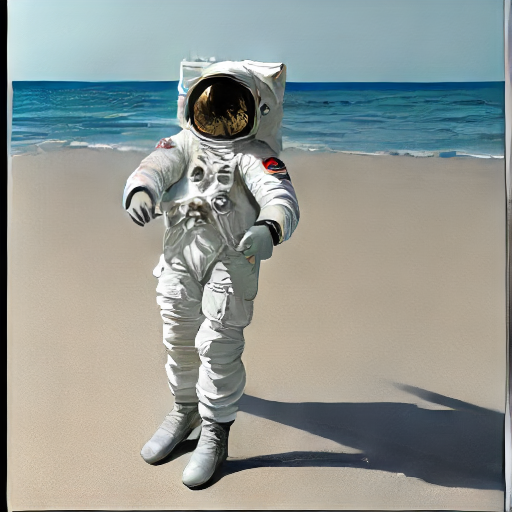

In [28]:
sigma = 14.6489
c_in = 1.0 / ((sigma**2 + 1)**0.5)
latents = torch.randn(1, 4, 64, 64)*sigma
latents.to(device)
with torch.no_grad():
    # THE ALIGNMENT STEP: 
    # Pipeline scales the input BEFORE the UNet
    model_input = latents * c_in
    
    # Use 999 (Trailing index for 1000)
    noise_pred = unet(
        model_input.to(device), 
        torch.tensor([1000], device=device), 
        encoder_hidden_states=prompt_embeds
    ).sample

# 2. THE SUBTRACTION (As you noted, this is mandatory)
# x0 = sample - sigma * noise_pred
latents_denoised = latents.to(device) - (sigma * noise_pred).to(device)

# 3. THE FINAL 0.1% ALIGNMENT (The VAE Input)
# In your working 99% code, you had: latents_for_decoder = latents * 14.61
# In the pipeline, it uses the magnitude/shift from the VAE config:
latents_for_decoder = (latents_denoised*1)

# 4. THE OUTPUT (The "Fuzzy" Fix)
# TAESD outputs 0-1. If you use /2+0.5 here, it ruins the alignment.
image_tensors = decoder(latents_for_decoder)
print(image_tensors.max())
print(image_tensors.min())
image = (image_tensors / 2 + 0.5).clamp(0, 1)


# Convert to PIL
image = image.cpu().permute(0, 2, 3, 1).float().detach().numpy()
image = (image * 255).round().astype("uint8")[0]
from PIL import Image
final_img = Image.fromarray(image)
final_img